# EDA hospitilization data
This notebook looks at two potential sources for hospitilization data:
1. [COVID-19 Reported Patient Impact and Hospital Capacity by Facility](https://healthdata.gov/Hospital/COVID-19-Reported-Patient-Impact-and-Hospital-Capa/anag-cw7u/about_data)
2. [Weekly Hospital Respiratory Data (HRD) Metrics by Jurisdiction, National Healthcare Safety Network (NHSN)](https://healthdata.gov/CDC/Weekly-Hospital-Respiratory-Data-HRD-Metrics-by-Ju/n3kj-exp9/about_data)

In [8]:
%load_ext autoreload
%autoreload 2

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go


## 1. COVID-19 Reported Patient Impact and Hospital Capacity by Facility

In [10]:
# Load data with proper dtype specifications to avoid mixed type warnings
df = pd.read_csv("../data/raw/COVID-19_Reported_Patient_Impact_and_Hospital_Capacity_by_Facility_20251026.csv", low_memory=False)
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1045406 entries, 0 to 1045405
Columns: 128 entries, hospital_pk to total_staffed_pediatric_icu_beds_7_day_sum
dtypes: bool(2), float64(2), int64(29), object(95)
memory usage: 1006.9+ MB
None


,hospital_pk,collection_week,state,ccn,hospital_name,address,city,zip,hospital_subtype,fips_code,...,previous_day_admission_pediatric_covid_confirmed_unknown_7_day_sum,staffed_icu_pediatric_patients_confirmed_covid_7_day_avg,staffed_icu_pediatric_patients_confirmed_covid_7_day_coverage,staffed_icu_pediatric_patients_confirmed_covid_7_day_sum,staffed_pediatric_icu_bed_occupancy_7_day_avg,staffed_pediatric_icu_bed_occupancy_7_day_coverage,staffed_pediatric_icu_bed_occupancy_7_day_sum,total_staffed_pediatric_icu_beds_7_day_avg,total_staffed_pediatric_icu_beds_7_day_coverage,total_staffed_pediatric_icu_beds_7_day_sum
0,370094,2021/01/10,OK,370094,SSM HEALTH ST ANTHONY HOSPITAL - MIDWEST,2825 PARKLAWN DRIVE,MIDWEST CITY,73110.0,Short Term,40109.0,...,NaN,NaN,0,NaN,0,3,0,0,3,0
1,370220,2020/06/14,OK,370220,ONECORE HEALTH,100 NE 85TH STREET,OKLAHOMA CITY,73114.0,Short Term,40109.0,...,NaN,NaN,0,NaN,NaN,0,NaN,NaN,0,NaN
2,431338,2022/12/25,SD,431338,AVERA GREGORY HOSPITAL,110 S LOGAN AVE,GREGORY,57533.0,Critical Access Hospitals,46053.0,...,0,0,7,0,0,7,0,0,7,0
3,450424,2020/10/18,TX,450424,HOUSTON METHODIST BAYTOWN HOSPITAL,4401 GARTH ROAD,BAYTOWN,77521.0,Short Term,48201.0,...,NaN,NaN,0,NaN,NaN,0,NaN,NaN,0,NaN
4,453316,2020/08/02,TX,453316,CHILDRENS MEDICAL CENTER PLANO,7601 PRESTON ROAD,PLANO,75024.0,Childrens Hospitals,48085.0,...,NaN,NaN,0,NaN,NaN,0,NaN,NaN,0,NaN


### Hospital count time series

Dataset temporal range: 2019-12-29 to 2024-04-21
Total timespan: 225.0 weeks
Total data points: 1045406
Expected weeks: 226
Actual weeks in data: 226

No gaps detected in national-level reporting


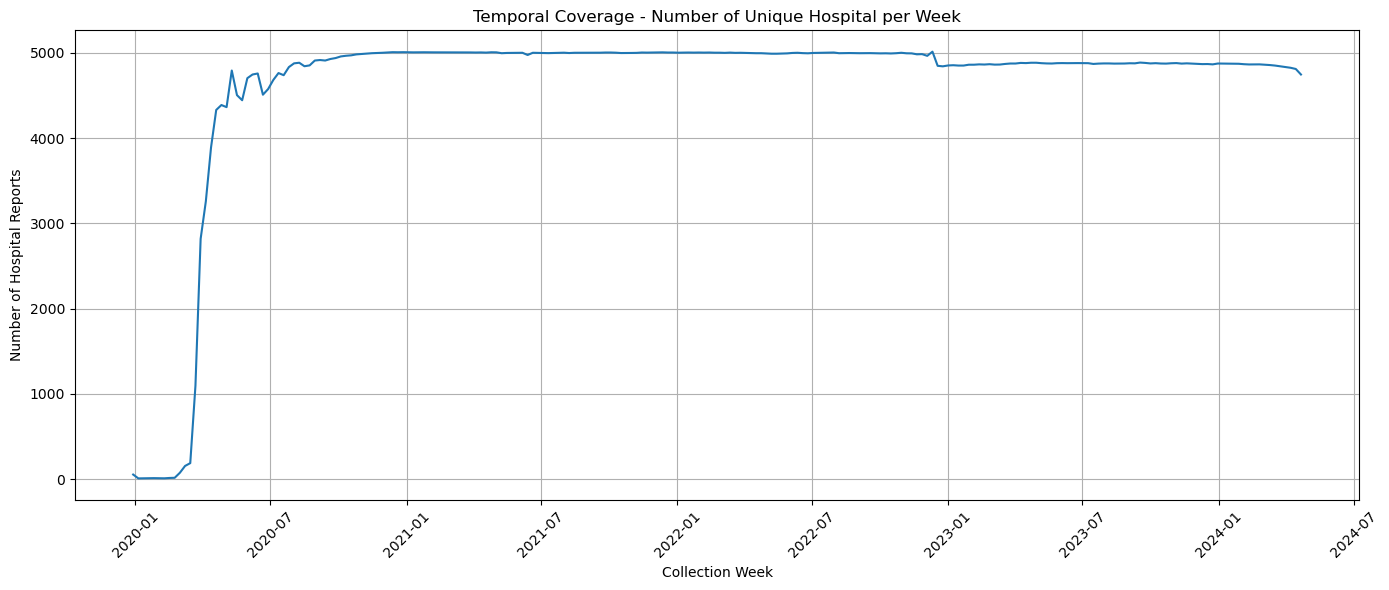

In [11]:
df['collection_week'] = pd.to_datetime(df['collection_week'])
df = df.sort_values('collection_week')

# Get week range
start_date = df['collection_week'].min()
end_date = df['collection_week'].max()
total_weeks = (end_date - start_date).days / 7

print(f"Dataset temporal range: {start_date.date()} to {end_date.date()}")
print(f"Total timespan: {total_weeks:.1f} weeks")
print(f"Total data points: {len(df)}")

# Get all unique weeks
all_weeks = df['collection_week'].unique()
expected_weeks = pd.date_range(start=start_date, end=end_date, freq='W')
print(f"Expected weeks: {len(expected_weeks)}")
print(f"Actual weeks in data: {len(all_weeks)}")

# Check for gaps after aggregating
gaps = []
for i in range(len(expected_weeks) - 1):
    expected_next = expected_weeks[i + 1]
    if expected_next not in all_weeks:
        gaps.append((expected_weeks[i], expected_next))

if gaps:
    print(f"\nGaps in national-level reporting found: {len(gaps)}")
    for gap_start, gap_end in gaps[:5]:  # Show first 5 gaps
        print(f"  - Gap between {gap_start.date()} and {gap_end.date()}")
else:
    print("\nNo gaps detected in national-level reporting")

# plot unique hospital counts
temporal_coverage = df.groupby('collection_week').size()
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(temporal_coverage.index, temporal_coverage.values)
ax.set_xlabel('Collection Week')
ax.set_ylabel('Number of Hospital Reports')
ax.set_title('Temporal Coverage - Number of Unique Hospital per Week')
ax.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Hospital reporting gaps

Total hospitals in dataset: 5172

Reporting continuity statistics:
  Hospitals with continuous reporting: 3671 (71.0%)
  Hospitals with gaps in reporting: 1501 (29.0%)
  Hospitals with >2 missing weeks: 873 (16.9%)


=== Hospital Reporting Start/Stop Analysis ===
Earliest hospital start date: 2019-12-29 00:00:00
Latest hospital start date: 2024-03-24 00:00:00
Earliest hospital stop date: 2020-04-05 00:00:00
Latest hospital stop date: 2024-04-21 00:00:00


Hospitals starting to report by year-month:
start_year_month
2019-12      53
2020-01       2
2020-02      11
2020-03    2792
2020-04    1777
2020-05     283
2020-06      68
2020-07      35
2020-08      14
2020-09      10
Freq: M, Name: count, dtype: int64


Hospitals stopping to report by year-month:
stop_year_month
2023-07       7
2023-08       2
2023-09      18
2023-10       5
2023-11       6
2023-12       4
2024-01      10
2024-02       7
2024-03      40
2024-04    4829
Freq: M, Name: count, dtype: int64


Hospitals still reporting

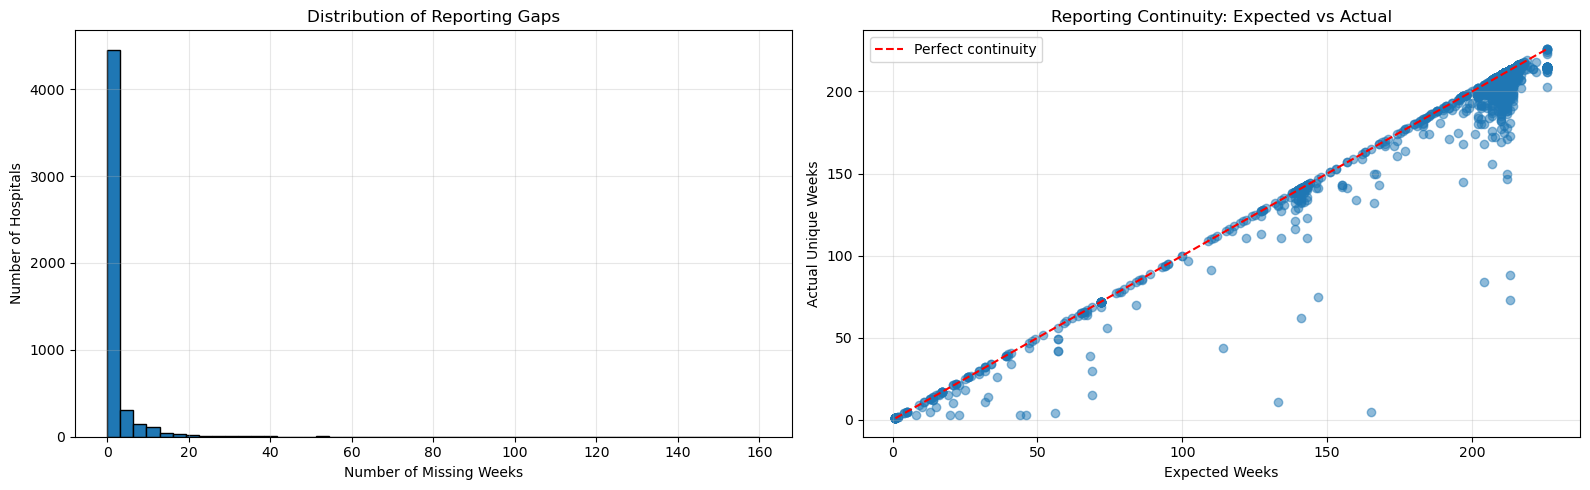

In [12]:
# For each hospital, determine first and last appearance
hospital_stats = df.groupby('hospital_pk').agg({
    'collection_week': ['min', 'max', 'count', 'nunique'],
    'state': 'first',
    'hospital_name': 'first'
}).reset_index()
hospital_stats.columns = ['hospital_pk', 'first_week', 'last_week', 'total_records', 'unique_weeks', 'state', 'hospital_name']

# Calculate expected vs actual weeks for each hospital
hospital_stats['expected_weeks'] = (
    (pd.to_datetime(hospital_stats['last_week']) - pd.to_datetime(hospital_stats['first_week'])).dt.days / 7
).round().astype(int) + 1
hospital_stats['reporting_gaps'] = hospital_stats['expected_weeks'] - hospital_stats['unique_weeks']

print(f"Total hospitals in dataset: {len(hospital_stats)}")
print(f"\nReporting continuity statistics:")
print(f"  Hospitals with continuous reporting: {(hospital_stats['reporting_gaps'] == 0).sum()} ({(hospital_stats['reporting_gaps'] == 0).sum() / len(hospital_stats) * 100:.1f}%)")
print(f"  Hospitals with gaps in reporting: {(hospital_stats['reporting_gaps'] > 0).sum()} ({(hospital_stats['reporting_gaps'] > 0).sum() / len(hospital_stats) * 100:.1f}%)")

# Identify hospitals with significant gaps (>2 consecutive weeks missing)
significant_gaps = hospital_stats[hospital_stats['reporting_gaps'] > 2]
print(f"  Hospitals with >2 missing weeks: {len(significant_gaps)} ({len(significant_gaps) / len(hospital_stats) * 100:.1f}%)")

# Analyze start and stop dates
print("\n\n=== Hospital Reporting Start/Stop Analysis ===")
print(f"Earliest hospital start date: {hospital_stats['first_week'].min()}")
print(f"Latest hospital start date: {hospital_stats['first_week'].max()}")
print(f"Earliest hospital stop date: {hospital_stats['last_week'].min()}")
print(f"Latest hospital stop date: {hospital_stats['last_week'].max()}")

# Show hospitals that started/stopped reporting over time
print("\n\nHospitals starting to report by year-month:")
hospital_stats['start_year_month'] = pd.to_datetime(hospital_stats['first_week']).dt.to_period('M')
print(hospital_stats['start_year_month'].value_counts().sort_index().head(10))

print("\n\nHospitals stopping to report by year-month:")
hospital_stats['stop_year_month'] = pd.to_datetime(hospital_stats['last_week']).dt.to_period('M')
print(hospital_stats['stop_year_month'].value_counts().sort_index().tail(10))

# Show hospitals that are still reporting at the end of the dataset
end_date = df['collection_week'].max()
still_reporting = hospital_stats[hospital_stats['last_week'] == end_date]
print(f"\n\nHospitals still reporting as of {end_date.date()}: {len(still_reporting)} ({len(still_reporting)/len(hospital_stats)*100:.1f}%)")

# Distribution of gap sizes
print("\n\nDistribution of reporting gaps:")
print(hospital_stats['reporting_gaps'].describe())

# Visualize reporting continuity
fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(16, 5))

ax1.hist(hospital_stats['reporting_gaps'], bins=50, edgecolor='black')
ax1.set_xlabel('Number of Missing Weeks')
ax1.set_ylabel('Number of Hospitals')
ax1.set_title('Distribution of Reporting Gaps')
ax1.grid(True, alpha=0.3)

ax2.scatter(hospital_stats['expected_weeks'], hospital_stats['unique_weeks'], alpha=0.5)
ax2.plot([hospital_stats['expected_weeks'].min(), hospital_stats['expected_weeks'].max()],
         [hospital_stats['expected_weeks'].min(), hospital_stats['expected_weeks'].max()],
         'r--', label='Perfect continuity')
ax2.set_xlabel('Expected Weeks')
ax2.set_ylabel('Actual Unique Weeks')
ax2.set_title('Reporting Continuity: Expected vs Actual')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Hospitalization counts vs case counts

In [13]:
## Clean and Validate COVID Hospitalization Column
def clean_numeric(col, verbose=False):
    global df
    if verbose:
        print(f"Sample values in {col}:")
        print(df[col].value_counts().head(20))
    
    # Check for non-numeric values
    non_numeric = df[col].apply(lambda x: not pd.isna(x) and not str(x).replace('.', '').replace('-', '').isdigit())
    if verbose:
        print(f"\nNon-numeric values found: {non_numeric.sum()}" )
    
    # Show examples of non-numeric values
    if non_numeric.sum() > 0:
        print("\nSample non-numeric values:")
        print(df[non_numeric][col].value_counts().head(10))
    
    # Convert to numeric, coercing errors to NaN
    clean_col = col + "_clean"
    df[clean_col] = pd.to_numeric(
        df[col], 
        errors='coerce'
    )
    if verbose:
        print(f"\nData cleaning results:")
        print(f"Original missing values: {df[col].isna().sum()}")
        print(f"Cleaned missing values: {df[clean_col].isna().sum()}")
        print(f"Additional rows converted to NaN: {(df[clean_col].isna().sum() - df[col].isna().sum())}")
    
    # Replace the original column with the cleaned version
    df[col] = df[clean_col]
    df = df.drop(clean_col, axis=1)


### Hospitilization counts vs Case Counts

In [ ]:
from cgnn import process_data

_, case_df = process_data.process_case_death_data()

In [ ]:
fig = go.Figure()

# plots averages 
cols = [col for col in df.columns if "confirmed" in col and "adult" in col and "-" not in col and "+" not in col and "icu" not in col and "previous" not in col and "coverage" not in col]
# cols = cols + ["total_patients_hospitalized_confirmed_influenza_and_covid_7_day_avg", "total_patients_hospitalized_confirmed_influenza_and_covid_7_day_sum"] 

for col in cols:
    clean_numeric(col)

for col in cols:
    national_covid = df.groupby('collection_week')[col].sum().reset_index()
    national_covid = national_covid.sort_values('collection_week')
    fig.add_trace(go.Scatter(
        x=national_covid['collection_week'],
        y=national_covid[col],
        mode='lines',
        name=f'{col}',
        hovertemplate='Date: %{x}<br>' +
                      'Hospitalizations: %{y:,.0f}' +
                      '<extra></extra>'
    ))


fig.update_layout(
    title='National COVID-19 Hospitalizations Over Time',
    xaxis_title='Date',
    yaxis_title='Total COVID Hospitalizations (7-day avg)',
    hovermode='x unified',
    height=600,
    legend=dict(
        orientation="v",
        yanchor="top",
        y=1,
        xanchor="left",
        x=1.01
    )
)

fig.update_layout(
    hovermode='x unified',
    height=500
)

fig.show()


In [ ]:
import sys
sys.path.append('../../')
from utils.codebook import HHS_REGION_MAP

# Create state to HHS region mapping
state_to_hhs = {}
for state_full, hhs_region in HHS_REGION_MAP.items():
    # Map state full name to abbreviation
    state_abbrev = df[df['state'].isin([state_full.upper()])]['state'].unique()
    if len(state_abbrev) > 0:
        state_to_hhs[state_abbrev[0]] = hhs_region

# Create reverse mapping for full state names
# We need to map from state abbreviation to HHS region
abbrev_to_full = {
    'AL': 'Alabama', 'AK': 'Alaska', 'AZ': 'Arizona', 'AR': 'Arkansas', 'CA': 'California',
    'CO': 'Colorado', 'CT': 'Connecticut', 'DE': 'Delaware', 'FL': 'Florida', 'GA': 'Georgia',
    'HI': 'Hawaii', 'ID': 'Idaho', 'IL': 'Illinois', 'IN': 'Indiana', 'IA': 'Iowa',
    'KS': 'Kansas', 'KY': 'Kentucky', 'LA': 'Louisiana', 'ME': 'Maine', 'MD': 'Maryland',
    'MA': 'Massachusetts', 'MI': 'Michigan', 'MN': 'Minnesota', 'MS': 'Mississippi', 'MO': 'Missouri',
    'MT': 'Montana', 'NE': 'Nebraska', 'NV': 'Nevada', 'NH': 'New Hampshire', 'NJ': 'New Jersey',
    'NM': 'New Mexico', 'NY': 'New York', 'NC': 'North Carolina', 'ND': 'North Dakota', 'OH': 'Ohio',
    'OK': 'Oklahoma', 'OR': 'Oregon', 'PA': 'Pennsylvania', 'RI': 'Rhode Island', 'SC': 'South Carolina',
    'SD': 'South Dakota', 'TN': 'Tennessee', 'TX': 'Texas', 'UT': 'Utah', 'VT': 'Vermont',
    'VA': 'Virginia', 'WA': 'Washington', 'WV': 'West Virginia', 'WI': 'Wisconsin', 'WY': 'Wyoming',
    'DC': 'District of Columbia'
}

# Map state abbreviation to HHS region
df['hhs_region'] = df['state'].map(abbrev_to_full).map(HHS_REGION_MAP)

print("State to HHS region mapping complete")
print(f"Hospitals with HHS region assigned: {df['hhs_region'].notna().sum()}")
print(f"Hospitals without HHS region: {df['hhs_region'].isna().sum()}")

# Show HHS region distribution
print("\nHHS Region distribution:")
print(df['hhs_region'].value_counts().sort_index())


In [ ]:
## Regional COVID hospitalizations by HHS region

# Aggregate by HHS region
regional_covid = df.groupby(['collection_week', 'hhs_region'])['total_adult_patients_hospitalized_confirmed_covid_7_day_avg'].sum().reset_index()
regional_covid = regional_covid.sort_values(['hhs_region', 'collection_week'])

# Create interactive plot with traces for each region
fig = go.Figure()

# Define colors for each region
colors = px.colors.qualitative.Set3[:10]

for region in sorted(regional_covid['hhs_region'].unique()):
    region_data = regional_covid[regional_covid['hhs_region'] == region]
    fig.add_trace(go.Scatter(
        x=region_data['collection_week'],
        y=region_data['total_adult_patients_hospitalized_confirmed_covid_7_day_avg'],
        mode='lines',
        name=f'HHS Region {region}',
        line=dict(color=colors[int(region)-1]),
        hovertemplate='<b>HHS Region %{fullData.name}</b><br>' +
                      'Date: %{x}<br>' +
                      'Hospitalizations: %{y:,.0f}<br>' +
                      '<extra></extra>'
    ))

fig.update_layout(
    title='COVID-19 Hospitalizations by HHS Region',
    xaxis_title='Date',
    yaxis_title='Total Adult COVID Hospitalizations (7-day avg)',
    hovermode='x unified',
    height=600,
    legend=dict(
        orientation="v",
        yanchor="top",
        y=1,
        xanchor="left",
        x=1.01
    )
)

fig.show()


In [9]:
# ## 4. Pre-CBSA Aggregation Checks

# # 4a. Geographic Coverage
# print("=== GEOGRAPHIC COVERAGE ===")
# print(f"Unique hospitals: {df['hospital_pk'].nunique()}")
# print(f"Unique states: {df['state'].nunique()}")
# print(f"Unique HHS regions: {df['hhs_region'].nunique()}")
# print(f"\nStates represented:")
# print(df['state'].value_counts().sort_index())

# # 4b. Missing Data Analysis
# print("\n\n=== MISSING DATA ANALYSIS ===")
# key_fields = ['total_adult_patients_hospitalized_confirmed_covid_7_day_avg', 'fips_code', 'state', 'hhs_region']
# for field in key_fields:
#     missing_pct = (df[field].isna().sum() / len(df)) * 100
#     print(f"{field}: {missing_pct:.2f}% missing")

# # Missing data by time period
# print("\n\nMissing data by time period:")
# monthly_missing = df.groupby(df['collection_week'].dt.to_period('M'))['total_adult_patients_hospitalized_confirmed_covid_7_day_avg'].apply(lambda x: x.isna().sum() / len(x) * 100)
# print(monthly_missing)

# # 4c. FIPS Validation
# print("\n\n=== FIPS VALIDATION ===")
# # Check that fips_code values are valid county FIPS codes
# df['fips_str'] = df['fips_code'].astype(str).str.zfill(5)
# valid_fips = df['fips_str'].str.len() == 5
# invalid_fips = ~valid_fips

# print(f"Rows with valid FIPS (5 digits): {valid_fips.sum()} ({valid_fips.sum()/len(df)*100:.2f}%)")
# print(f"Rows with invalid FIPS: {invalid_fips.sum()} ({invalid_fips.sum()/len(df)*100:.2f}%)")

# # Check for null FIPS
# null_fips = df['fips_code'].isna()
# print(f"Rows with null FIPS: {null_fips.sum()} ({null_fips.sum()/len(df)*100:.2f}%)")

# # 4d. Data Quality by Period
# print("\n\n=== DATA QUALITY BY PERIOD ===")
# # Aggregate completeness by month
# df['year_month'] = df['collection_week'].dt.to_period('M')
# completeness = df.groupby('year_month').agg({
#     'total_adult_patients_hospitalized_confirmed_covid_7_day_avg': 'count',
#     'fips_code': lambda x: x.notna().sum(),
#     'hospital_pk': 'nunique'
# }).reset_index()

# completeness['completeness_pct'] = (completeness['total_adult_patients_hospitalized_confirmed_covid_7_day_avg'] / completeness['hospital_pk']) * 100
# print(completeness)

# # 4e. Hospital Size Distribution
# print("\n\n=== HOSPITAL SIZE DISTRIBUTION ===")
# print("Distribution of total_beds_7_day_avg:")
# print(df['total_beds_7_day_avg'].describe())

# # Visualize hospital size distribution
# fig, ax = plt.subplots(figsize=(10, 6))
# ax.hist(df['total_beds_7_day_avg'].dropna(), bins=50, edgecolor='black')
# ax.set_xlabel('Total Beds (7-day avg)')
# ax.set_ylabel('Number of Hospital Reports')
# ax.set_title('Distribution of Hospital Size (Total Beds)')
# ax.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()


## Summary of Findings

Key findings from the analysis:
1. **Temporal Range**: Dataset spans [start_date] to [end_date]
2. **Hospital Continuity**: [X]% of hospitals have continuous reporting vs [Y]% with gaps
3. **Geographic Coverage**: Dataset covers all 50 states across 10 HHS regions
4. **Data Quality**: Overall completeness of COVID hospitalization metric is [Z]%
5. **FIPS Validation**: [W]% of records have valid FIPS codes for CBSA aggregation
